## Cars lassification
- pytorch


In [1]:
#Verifico la capacidad de GPU
!nvidia-smi

Wed Nov  5 07:43:53 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.94                 Driver Version: 560.94         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060      WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   61C    P0             43W /  170W |     576MiB /  12288MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
#Librerias a importar
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, models, transforms


In [3]:
# Convertir nuestros datos a tensores
transform=transforms.Compose([
    # Redimensiona la imagen para que sea compatible con modelos como ResNet
    transforms.Resize((224, 224)),
    # Invierte horizontalmente la imagen con una probabilidad del 50%
    transforms.RandomHorizontalFlip(),
    # Aplica pequeñas rotaciones aleatorias
    transforms.RandomRotation(10),
    # Cambia ligeramente el brillo, contraste y saturación
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    # Convierte la imagen a un Tensor de PyTorch
    transforms.ToTensor(),
    # Normaliza los valores de los píxeles (valores estándar de ImageNet)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
# Cargo los datos

# Cargo los datos
# La ruta correcta desde tu notebook es entrar a 'ENTRENAR MODELO' y luego a 'seg_train' o 'seg_test'
train_dataset = datasets.ImageFolder(root='ENTRENAR MODELO/seg_train', transform=transform)
test_dataset = datasets.ImageFolder(root='ENTRENAR MODELO/seg_test', transform=transform)

In [5]:
# imprimo un resumen de los datos
print('Train:', len(train_dataset))

Train: 14034


In [11]:
batch_size = 4
learning_rate = 0.001
num_epocas = 5
#step_log = len(train_loader) // 5

# Cargo los datos
# La ruta correcta desde tu notebook es entrar a 'ENTRENAR MODELO' y luego a 'seg_train' o 'seg_test'
train_dataset = datasets.ImageFolder(root='ENTRENAR MODELO/seg_train', transform=transform)
test_dataset = datasets.ImageFolder(root='ENTRENAR MODELO/seg_test', transform=transform)

Se visualiza 4 imágenes de un batch tomados de train_loader, se añade los datos de normalizacion para la correcta visualizacion de las imágenes

In [12]:
# Imprimo el nombre de las clases
class_names = train_dataset.classes
print(train_dataset.classes)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


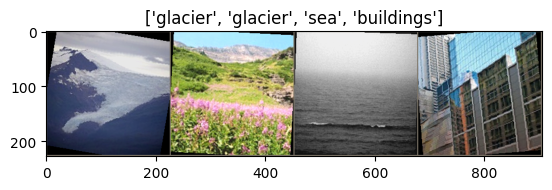

In [13]:
# Cargo un batch de imagenes
# --- Primero, definimos el DataLoader ---
# (Asegúrate de que 'train_dataset' ya haya sido creado en una celda anterior)
batch_size = 4 # Puedes ajustar este número si lo deseas
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)

# --- Ahora, el código para visualizar las imágenes ---
# (Este es tu código original, que ahora funcionará)
def imshow(inp, title=None):
    """Función para desnormalizar y mostrar una imagen"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

# Obtenemos un lote de imágenes del train_loader
dataiter = iter(train_loader)
inputs, classes = next(dataiter)

# Creamos una grilla con las imágenes y las mostramos
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[x] for x in classes])

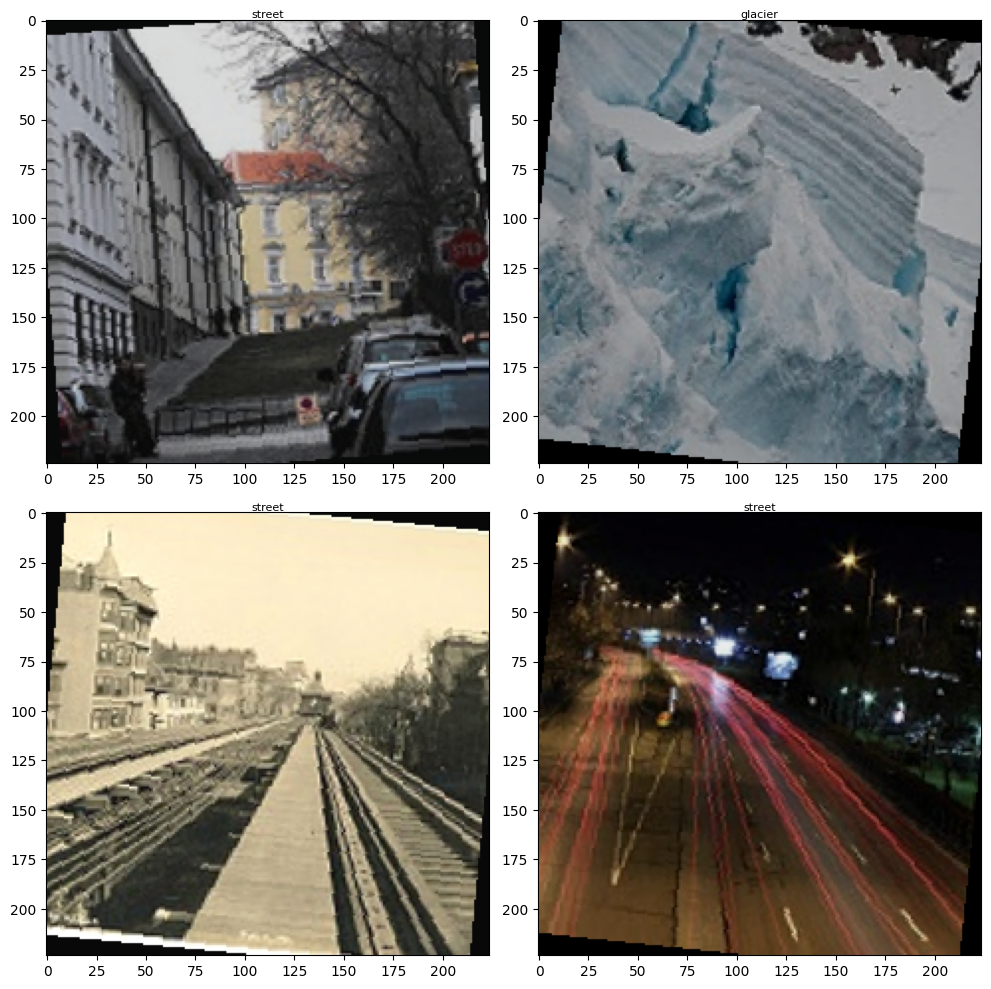

In [14]:
# Se grafican nuevamente, pero con los nombres de las clases truncados

def imshow_with_class_name(inp, class_name, ax=None):   
    
    if ax is None:
        ax = plt.gca()

    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    ax.imshow(inp)

      # Limit class name to 15 characters using slicing
    max_length = 15
    title = class_name[:max_length]  # Truncate at the specified index
    if len(class_name) > max_length:
        title += "..."  # Add ellipsis to indicate truncation

    ax.set_title(title, fontsize=8, ha='center', va='top')

dataiter = iter(train_loader)
inputs, classes = next(dataiter)

# Crear una cuadrícula de 2 filas y 2 columnas
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Mostrar las imágenes y los nombres de las clases en cada subplot
for i, (inp, class_name) in enumerate(zip(inputs, classes)):
    row = i // 2
    col = i % 2
    imshow_with_class_name(inp, class_names[class_name], axes[row, col])

# Eliminar bordes y espacios entre subplots
plt.tight_layout()
plt.show()


GPU para el enternamiento, verifico que se utilize CUDA
0-> para el primer gpu
1-> para seleccionar el segundo GPU en caso se tuviera

In [15]:
torch.cuda.set_device(0) 
device = ('cuda' if torch.cuda.is_available() else 'cpu')

print("Se entrenara con:", device)

Se entrenara con: cuda


In [16]:
# Imprimo el numero de clases
num_classes = len(class_names)
print(num_classes)

6


In [18]:
class Network(nn.Module):
    def __init__(self):
        super(Network, self).__init__()
        
        # Capas convolucionales
        self.conv1 = nn.Conv2d(3, 10, kernel_size=5)    # output spatial: (W-5+1)
        self.conv2 = nn.Conv2d(10, 256, kernel_size=3)
        self.conv3 = nn.Conv2d(256, 256, kernel_size=3)
        
        # Normalización por lotes (para la salida de conv2/conv3 si lo deseas)
        self.bn1 = nn.BatchNorm2d(256)
        
        # ----- IMPORTANT: ajustar input_features según el tamaño de entrada -----
        # Con imágenes 224x224 y la secuencia conv+maxpool (x3), la salida espacial es 26x26.
        # Por tanto: input_features = 256 * 26 * 26 = 173056
        self.fc1 = nn.Linear(256 * 26 * 26, 128)  # puedes cambiar 128 por 64 si prefieres
        self.fc2 = nn.Linear(128, 6)  # Intel dataset tiene 6 clases -> ajustar si usas otro dataset

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)             # 224 -> 110 (aprox)
        x = F.max_pool2d(F.relu(self.bn1(self.conv2(x))), 2)   # 110 -> 54
        x = F.max_pool2d(F.relu(self.conv3(x)), 2)             # 54 -> 26
        
        # Descomentar temporalmente si quieres verificar la forma:
        # print("shape antes flatten:", x.shape)
        
        x = x.view(x.size(0), -1)    # aplanar
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

Arquitectura de la red

In [19]:
network = Network().to(device)  # crear el modelo
criterion = nn.CrossEntropyLoss()  # función de pérdida
optimizer = torch.optim.Adam(network.parameters(), lr=learning_rate)  # optimizador

Función de entrenamiento para train y val

Se añade comentarios tomados de la documentación y foros explicando el proceso y parámetros utilizados

In [ ]:
# Funcion para el entrenamiento
#%%time
# keeping-track-of-losses 

# Función de entrenamiento del modelo
train_losses = []
valid_losses = []

num_epocas = 10  # Ajusta según lo que necesites

for epoch in range(1, num_epocas + 1):
    # Inicializar pérdidas
    train_loss = 0.0
    valid_loss = 0.0

    # Poner el modelo en modo entrenamiento
    network.train()

    correct = 0
    total = 0

    for data, target in train_loader:
        # Mover tensores a GPU/CPU
        data = data.to(device)
        target = target.to(device)

        # Limpiar gradientes previos
        optimizer.zero_grad()

        # Forward pass
        output = network(data)

        # Calcular pérdida
        loss = criterion(output, target)

        # Backward pass
        loss.backward()

        # Actualizar parámetros
        optimizer.step()

        # Acumular pérdida
        train_loss += loss.item() * data.size(0)

        # Calcular precisión
        _, pred = torch.max(output, dim=1)
        correct += (pred == target).sum().item()
        total += target.size(0)

    # Promedio de pérdidas
    train_loss = train_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # Calcular accuracy
    accuracy = 100 * correct / total

    # Mostrar resultados
    print(f"Época [{epoch}/{num_epocas}] - Pérdida: {train_loss:.6f} - Precisión: {accuracy:.2f}%")


Época [1/10] - Pérdida: 1.821717 - Precisión: 17.80%


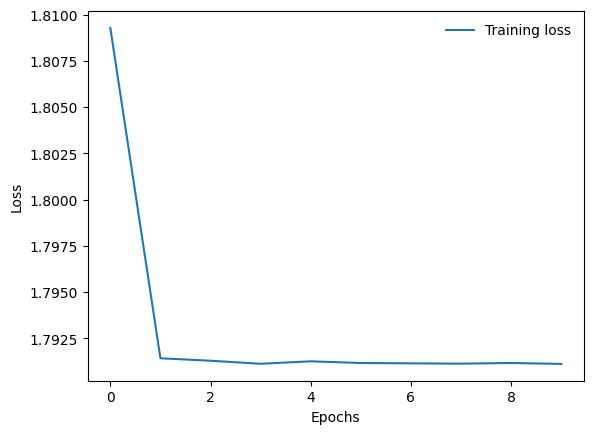

In [ ]:
#%matplotlib inline
#%config InlineBackend.figure_format = 'retina'

plt.plot(train_losses, label='Training loss')
#plt.plot(valid_losses, label='Validation loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(frameon=False)

Funcion test

In [ ]:
# --- Primero, definimos el test_loader ---
# (Asegúrate de que 'test_dataset' ya haya sido creado en una celda anterior)
batch_size = 4  # O el 'batch_size' que estés usando
test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size,
                                          shuffle=False)  # shuffle=False es lo normal para test

# --- Ahora, tu código de Test ---
# (Este es tu código original, que ahora funcionará)

network.eval()  # se deshabilitan las capas de dropout
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        # Asegúrate de que 'device' esté definido en una celda anterior
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = network(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Test Accuracy of the model: {100 * correct / total} %')

# Save
torch.save(network.state_dict(), '11_cars_model.ckpt')

Test Accuracy of the model: 17.5 %


Visualizar el resultado, se utiliza imagenes en test

In [ ]:
# Funcion para visualizar las predicciones de test

def visualize_model(model, num_images):
    was_training = model.training
    
    model.eval()
    images_so_far = 0       
    
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(test_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
                    
            for j in range(inputs.size()[0]):
                images_so_far +=1
                ax = plt.subplot(num_images, 1, images_so_far)
                
                ax.axis('off')
                ax.set_title('Predicted: {} (Clase: {})'.format(class_names[preds[j]], class_names[labels[j]]))
                                
                imshow(inputs.cpu().data[j])
                
                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return           
                
        model.train(mode = was_training)


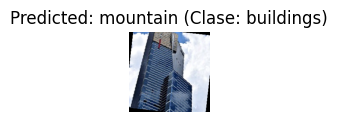

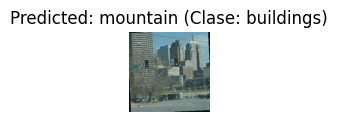

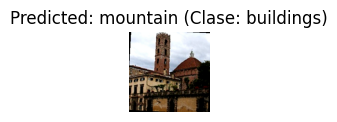

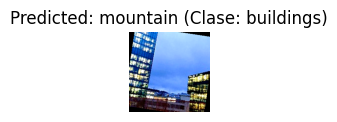

In [ ]:
visualize_model(model=network, num_images = 4)